In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
BASE = "/content/drive/MyDrive/Market_Microstructure"

# mettre BASE tout en premier
if BASE in sys.path:
    sys.path.remove(BASE)
sys.path.insert(0, BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from state import LOBState
from intensities import make_default_dummy_intensity
from models.model1 import Model1IndependentQueues
from simulator import CTMCSimulator
from analysis import *

from mle import load_lobster_day, fit_model1_mle_from_lobster, EmpiricalIntensityModel

message_path  = os.path.join(BASE, "data", "LOBSTER_SampleFile_INTC_2012-06-21_5",
                             "INTC_2012-06-21_34200000_57600000_message_5.csv")
orderbook_path = os.path.join(BASE, "data", "LOBSTER_SampleFile_INTC_2012-06-21_5",
                              "INTC_2012-06-21_34200000_57600000_orderbook_5.csv")

msg, ob, df = load_lobster_day(message_path, orderbook_path, levels=5)

mle = fit_model1_mle_from_lobster(msg, ob, K=5, n_max=50_000)
emp_intensity = EmpiricalIntensityModel(mle)

dummy_intensity = make_default_dummy_intensity(K=3)

state0 = LOBState(K=3, q0=[0]*6)
model = Model1IndependentQueues(intensity=dummy_intensity)
sim = CTMCSimulator(model=model, seed=42)
final_state, res = sim.run(state0, T=30.0)


In [3]:
dummy_intensity

DummyIntensityModel(K=3, a_L=(np.float64(6.0), np.float64(4.0), np.float64(2.0)), b_C=(np.float64(0.6), np.float64(0.44999999999999996), np.float64(0.3)), m_M=(3.0, 0.2, 0.2), eps=0.0)

In [4]:
fig = animate_lob_with_tns(state0, res, step=1, last_n_events=15)
fig.show()

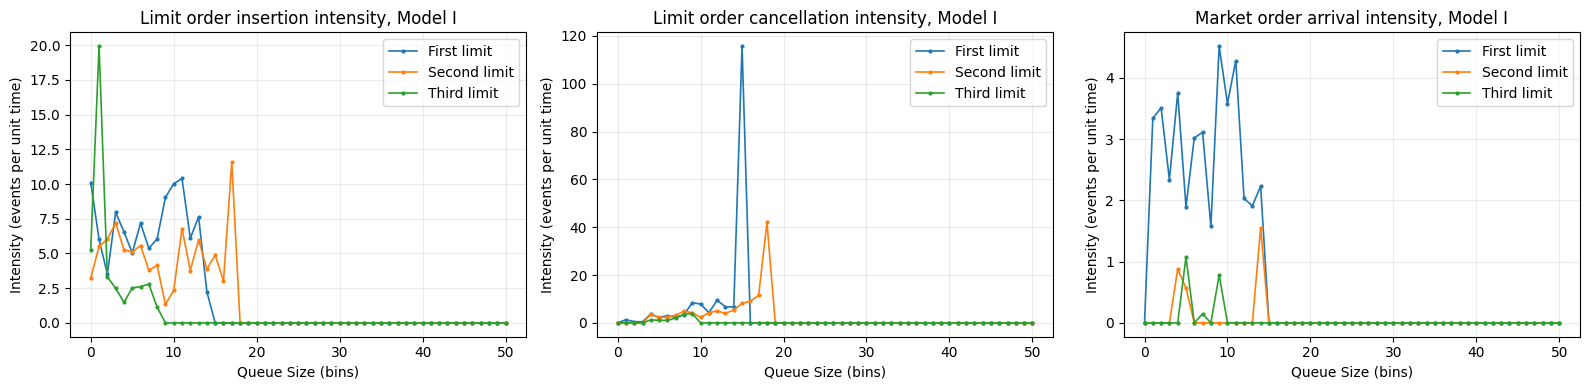

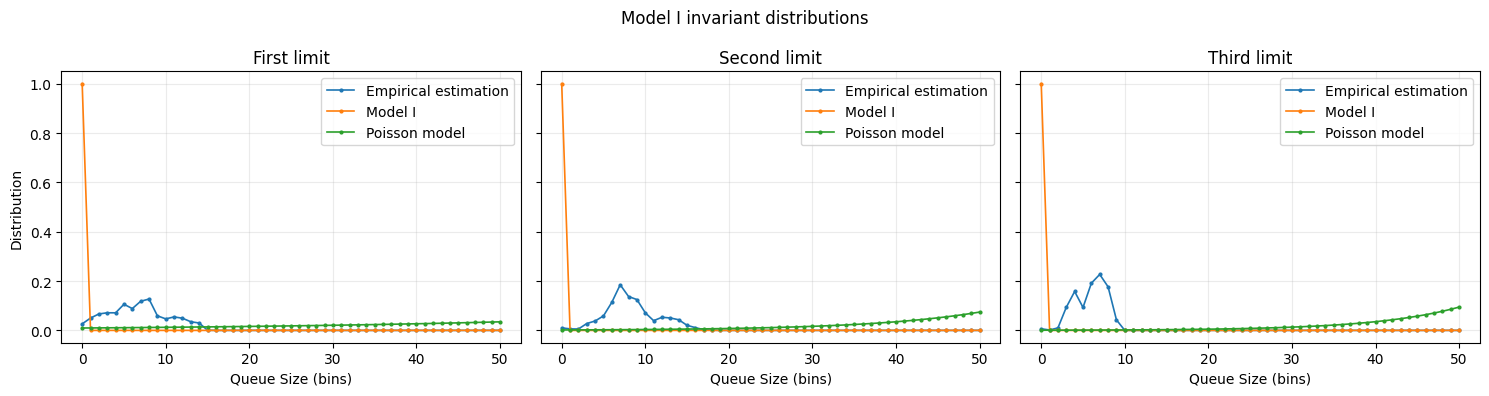

In [5]:
# after running the simulator and having (state0, res)
est = estimate_empirical_intensities(state0, res, n_max=50)

# Figure 2-like (empirical solid + model dashed)
plot_intensities_model1(est, emp_intensity, K=state0.K, use_empirical=True)

# Figure 3-like
plot_invariant_distributions_model1(est, emp_intensity, K=state0.K)

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Optional, Literal

MSG_COLS = ["time", "type", "order_id", "size", "price", "direction"]
LOBSTER_KIND = {1: "L", 2: "C", 3: "C", 4: "M", 5: "M"}

KindStr = Literal["L", "C", "M"]
SideStr = Literal["ask", "bid"]

def make_orderbook_cols(levels: int) -> list[str]:
    cols=[]
    for lvl in range(1, levels+1):
        cols += [f"ask_px_{lvl}", f"ask_sz_{lvl}", f"bid_px_{lvl}", f"bid_sz_{lvl}"]
    return cols

def event_kind_from_type(t: int) -> Optional[KindStr]:
    return LOBSTER_KIND.get(int(t), None)

def affected_side(kind: KindStr, direction: int) -> SideStr:
    d = int(direction)
    if kind in ("L", "C"):
        return "bid" if d == 1 else "ask"
    else:
        return "ask" if d == 1 else "bid"

def find_level_index(price: int, pre_px_row: np.ndarray) -> int:
    px = int(price)
    for j in range(pre_px_row.shape[0]):
        if int(pre_px_row[j]) == px:
            return j+1
    return 0

def compute_signed_price_level(row: pd.Series, K: int) -> int:
    kind = row["type"]
    if kind is None:
        return 0
    side = affected_side(kind, int(row["direction"]))
    px_cols = [f"{side}_px_{i}" for i in range(1, K + 1)]
    pre_px = row[px_cols].to_numpy(dtype=np.int64)

    lvl = find_level_index(int(row["price"]), pre_px)
    if lvl == 0:
        return 0
    return lvl if side == "ask" else -lvl

In [7]:
def load_lobster_data(
    message_csv: str | Path,
    orderbook_csv: str | Path,
    levels: int,
    K: int,
    market_open_seconds: float = 3600 * 9.5,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    message_csv = Path(message_csv)
    orderbook_csv = Path(orderbook_csv)

    # original dataframes
    msg = pd.read_csv(message_csv, header=None, names=MSG_COLS)
    ob = pd.read_csv(orderbook_csv, header=None, names=make_orderbook_cols(levels))
    if len(msg) != len(ob):
        raise ValueError(f"Row mismatch: message={len(msg)}, orderbook={len(ob)}")

    # types
    msg["time"] = msg["time"].astype(float)
    msg["type"] = msg["type"].astype(int)
    msg["size"] = msg["size"].astype(np.int64)
    msg["price"] = msg["price"].astype(np.int64)
    msg["direction"] = msg["direction"].astype(int)

    # base df = msg + ob
    df = pd.concat([msg, ob], axis=1)

    df["delta_time"] = df["time"].diff()
    df.loc[df.index[0], "delta_time"] = df.loc[df.index[0], "time"] - market_open_seconds

    # map types -> L/C/M
    df["type"] = df["type"].apply(event_kind_from_type)

    # signed level in top-K of the order book
    if K > levels:
        raise ValueError(f"K={K} cannot exceed levels={levels}")
    df["price_level"] = df.apply(lambda r: compute_signed_price_level(r, K=K), axis=1)

    df = df[["time", "delta_time", "type", "price_level", "price", "size"] + make_orderbook_cols(levels)]

    return msg, ob, df



In [8]:
msg, ob, df = load_lobster_data(message_path, orderbook_path, levels=5, K=5)
df

,time,delta_time,type,price_level,price,size,ask_px_1,ask_sz_1,bid_px_1,bid_sz_1,...,bid_px_3,bid_sz_3,ask_px_4,ask_sz_4,bid_px_4,bid_sz_4,ask_px_5,ask_sz_5,bid_px_5,bid_sz_5
0,34200.005743,0.005743,M,0,275200,34,275200,66,275100,400,...,274900,200,275600,100,274800,661,275700,100,274700,300
1,34200.006241,0.000498,L,1,275200,100,275200,166,275100,400,...,274900,200,275600,100,274800,661,275700,100,274700,300
2,34200.006462,0.000221,L,4,275500,100,275200,166,275100,400,...,274900,200,275500,100,274800,661,275600,100,274700,300
3,34200.048864,0.042402,C,0,275000,100,275200,166,275100,400,...,274800,661,275500,100,274700,300,275600,100,274600,700
4,34200.048883,0.000020,C,-1,275100,100,275200,166,275100,300,...,274800,661,275500,100,274700,300,275600,100,274600,700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581025,57599.860444,0.011408,C,1,267200,34600,267200,88104,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174
581026,57599.860635,0.000191,L,-2,267000,16600,267200,88104,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174
581027,57599.870108,0.009473,C,3,267400,600,267200,88104,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174
581028,57599.939645,0.069536,L,1,267200,100,267200,88204,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174


In [9]:
df

,time,delta_time,type,price_level,price,size,ask_px_1,ask_sz_1,bid_px_1,bid_sz_1,...,bid_px_3,bid_sz_3,ask_px_4,ask_sz_4,bid_px_4,bid_sz_4,ask_px_5,ask_sz_5,bid_px_5,bid_sz_5
0,34200.005743,0.005743,M,0,275200,34,275200,66,275100,400,...,274900,200,275600,100,274800,661,275700,100,274700,300
1,34200.006241,0.000498,L,1,275200,100,275200,166,275100,400,...,274900,200,275600,100,274800,661,275700,100,274700,300
2,34200.006462,0.000221,L,4,275500,100,275200,166,275100,400,...,274900,200,275500,100,274800,661,275600,100,274700,300
3,34200.048864,0.042402,C,0,275000,100,275200,166,275100,400,...,274800,661,275500,100,274700,300,275600,100,274600,700
4,34200.048883,0.000020,C,-1,275100,100,275200,166,275100,300,...,274800,661,275500,100,274700,300,275600,100,274600,700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581025,57599.860444,0.011408,C,1,267200,34600,267200,88104,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174
581026,57599.860635,0.000191,L,-2,267000,16600,267200,88104,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174
581027,57599.870108,0.009473,C,3,267400,600,267200,88104,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174
581028,57599.939645,0.069536,L,1,267200,100,267200,88204,267100,7191,...,266900,28495,267500,59278,266800,46883,267600,60383,266700,58174


In [10]:
msg

,time,type,order_id,size,price,direction
0,34200.005743,4,15835012,34,275200,-1
1,34200.006241,1,16114545,100,275200,-1
2,34200.006462,1,16114695,100,275500,-1
3,34200.048864,3,16063194,100,275000,1
4,34200.048883,3,15833239,100,275100,1
...,...,...,...,...,...,...
581025,57599.860444,3,287139444,34600,267200,-1
581026,57599.860635,1,287166269,16600,267000,1
581027,57599.870108,3,287016725,600,267400,-1
581028,57599.939645,1,287173095,100,267200,-1
